## Cell 0 – Install dependencies

In [1]:
# Run once in Colab
!pip install -q umap-learn scikit-learn

## Cell 1 – Mount Google Drive & extract dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

ZIP_PATH  = '/content/drive/MyDrive/medical_mnist.zip'   # <-- update if needed
EXTRACT_TO = '/content/medical_mnist'

if not os.path.isdir(EXTRACT_TO):
    print('Extracting...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_TO)
    print('Done.')
else:
    print('Already extracted.')

# Quick sanity check
for d in os.listdir(EXTRACT_TO):
    n = len(os.listdir(os.path.join(EXTRACT_TO, d)))
    print(f'  {d}: {n} images')

Mounted at /content/drive
Extracting...
Done.
  HeadCT: 10000 images
  BreastMRI: 8954 images
  ChestCT: 10000 images
  AbdomenCT: 10000 images
  CXR: 10000 images
  Hand: 10000 images


## Cell 2 – Configuration

In [2]:
import sys, os
import zipfile
import re
import importlib

CODEBASE_ZIP_PATH = '/content/dsai490_ae_vae_codebase.zip'
EXTRACT_TO_BASE = '/content/dsai490_ae_vae_codebase'

if not os.path.isdir(EXTRACT_TO_BASE):
    print(f'Extracting codebase from {CODEBASE_ZIP_PATH} to {EXTRACT_TO_BASE}...')
    with zipfile.ZipFile(CODEBASE_ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_TO_BASE)
    print('Codebase extraction complete.')
else:
    print(f'Codebase already extracted to {EXTRACT_TO_BASE}.')


REPO_ROOT = EXTRACT_TO_BASE
contents = os.listdir(EXTRACT_TO_BASE)
if len(contents) == 1 and os.path.isdir(os.path.join(EXTRACT_TO_BASE, contents[0])):
    REPO_ROOT = os.path.join(EXTRACT_TO_BASE, contents[0])
print(f"Set REPO_ROOT to: {REPO_ROOT}")

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print(f"Contents of {REPO_ROOT}: {os.listdir(REPO_ROOT)}")

config_path = os.path.join(REPO_ROOT, 'configs', 'config.py')

with open(config_path, 'r') as f:
    config_content = f.read()

original_config_content = config_content

config_content = re.sub(
    r'(ANATOMICAL_REGIONS\s*=\s*\[[^\]]*)"ChestXRay"([^\]]*\])',
    r'\g<1>"CXR"\g<2>',
    config_content, flags=re.DOTALL
)

if config_content != original_config_content:
    with open(config_path, 'w') as f:
        f.write(config_content)
    print("✓ config.py patched: 'ChestXRay' replaced with 'CXR'.")
    for mod_name in list(sys.modules.keys()):
        if 'config' in mod_name and 'configs.config' in mod_name:
            del sys.modules[mod_name]
    import configs.config as cfg
else:
    print("config.py already correctly defines ANATOMICAL_REGIONS or no change needed.")
    import configs.config as cfg

cfg.DATA_ROOT = '/content/medical_mnist'
cfg.ANATOMICAL_REGIONS = ['AbdomenCT', 'BreastMRI', 'ChestCT', 'CXR', 'Hand', 'HeadCT']

print('DATA_ROOT set to:', cfg.DATA_ROOT)
print('Regions:', cfg.ANATOMICAL_REGIONS)
print('Latent dim:', cfg.LATENT_DIM)
print('Batch size:', cfg.BATCH_SIZE)

Extracting codebase from /content/dsai490_ae_vae_codebase.zip to /content/dsai490_ae_vae_codebase...
Codebase extraction complete.
Set REPO_ROOT to: /content/dsai490_ae_vae_codebase/dsai490_ae_vae
Contents of /content/dsai490_ae_vae_codebase/dsai490_ae_vae: ['utils', 'experiment_notebook.ipynb', 'training', 'README.md', 'technical_report.docx', 'models', 'configs', '{models,utils,training,configs,outputs}']
✓ config.py patched: 'ChestXRay' replaced with 'CXR'.
DATA_ROOT set to: /content/medical_mnist
Regions: ['AbdomenCT', 'BreastMRI', 'ChestCT', 'CXR', 'Hand', 'HeadCT']
Latent dim: 16
Batch size: 64


## Cell 3 – Dataset inspection

__init__.py already exists in /content/dsai490_ae_vae_codebase/dsai490_ae_vae/utils.
AbdomenCT     total=10000  train= 8500  val=1500  batches/epoch=133
BreastMRI     total= 8954  train= 7611  val=1343  batches/epoch=119
ChestCT       total=10000  train= 8500  val=1500  batches/epoch=133
CXR           total=10000  train= 8500  val=1500  batches/epoch=133
Hand          total=10000  train= 8500  val=1500  batches/epoch=133
HeadCT        total=10000  train= 8500  val=1500  batches/epoch=133


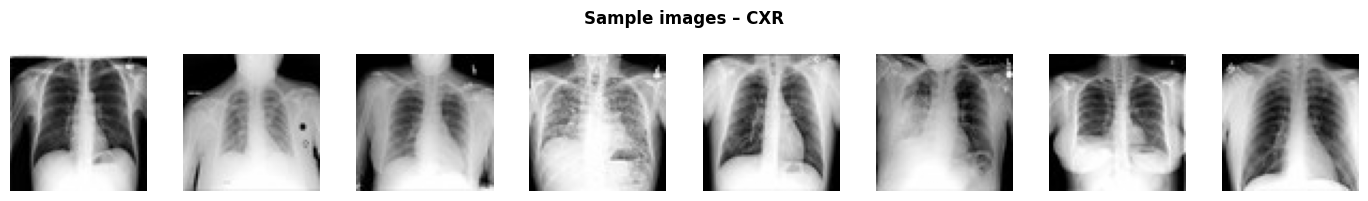

In [3]:
import os
import sys
import importlib
import matplotlib.pyplot as plt

EXTRACT_TO_BASE = '/content/dsai490_ae_vae_codebase'
REPO_ROOT = EXTRACT_TO_BASE
contents = os.listdir(EXTRACT_TO_BASE)
if len(contents) == 1 and os.path.isdir(os.path.join(EXTRACT_TO_BASE, contents[0])):
    REPO_ROOT = os.path.join(EXTRACT_TO_BASE, contents[0])

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import configs.config as cfg

utils_path = os.path.join(REPO_ROOT, 'utils')
init_file_path = os.path.join(utils_path, '__init__.py')

if not os.path.exists(init_file_path):
    os.makedirs(utils_path, exist_ok=True)
    with open(init_file_path, 'w') as f:
        pass
    print(f"Created empty __init__.py in {utils_path} to make it a package.")
else:
    print(f"__init__.py already exists in {utils_path}.")

import utils.data_loader
from utils.data_loader import dataset_info, get_sample_batch


importlib.reload(utils.data_loader)
from utils.data_loader import dataset_info, get_sample_batch

for region in cfg.ANATOMICAL_REGIONS:
    info = dataset_info(region)
    print(f"{info['region']:12s}  total={info['total']:5d}  "
          f"train={info['train']:5d}  val={info['val']:4d}  "
          f"batches/epoch={info['batches_train']}")

PREVIEW_REGION = 'CXR'
sample = get_sample_batch(PREVIEW_REGION, n=8)

fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(sample[i, ..., 0], cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
fig.suptitle(f'Sample images – {PREVIEW_REGION}', fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 4 – Patch `trainer.py` (fix EarlyStopping `mode` for AE & VAE)

In [4]:

import os, re, importlib, sys

trainer_path = os.path.join(REPO_ROOT, 'training', 'trainer.py')

with open(trainer_path, 'r') as f:
    content = f.read()

original = content

def _add_mode_min(match):
    """Insert mode='min' into a callback constructor that lacks it."""
    s = match.group(0)
    if 'mode=' in s:
        return s
    return s.replace('monitor=', "mode='min', monitor=", 1)

pattern = re.compile(
    r'(EarlyStopping|ModelCheckpoint|ReduceLROnPlateau)\s*\([^)]*monitor\s*=[^)]*\)',
    re.DOTALL
)
content = pattern.sub(_add_mode_min, content)

if content != original:
    with open(trainer_path, 'w') as f:
        f.write(content)
    print(f"✓ trainer.py patched — mode='min' added to all EarlyStopping, ModelCheckpoint, and ReduceLROnPlateau callbacks.")
else:
    print("trainer.py already patched — no changes needed.")

for mod_name in list(sys.modules.keys()):
    if 'trainer' in mod_name or 'training' in mod_name:
        del sys.modules[mod_name]
print("✓ Trainer module cache cleared.")

✓ trainer.py patched — mode='min' added to all EarlyStopping, ModelCheckpoint, and ReduceLROnPlateau callbacks.
✓ Trainer module cache cleared.


## Cell 5 – Train ALL AE models (one per region)

In [5]:
from training.trainer import train_autoencoder

ae_results = {}

for region in cfg.ANATOMICAL_REGIONS:
    print(f'\nTraining AE for region: {region} ...')
    try:
        result = train_autoencoder(
            region,
            denoising=True,
            epochs=cfg.AE_EPOCHS,
            verbose=1,
        )
        if result:
            ae_results[region] = result
            print(f'  ✓ AE trained for {region}.')
        else:
            print(f'  ⚠ train_autoencoder returned None for {region} — skipping.')
    except Exception as exc:
        import traceback
        print(f'  ✗ AE training failed for {region}: {exc}')
        traceback.print_exc()

print(f'\n✓ AE training complete. Regions trained: {list(ae_results.keys())}')



Training AE for region: AbdomenCT ...

───────────────────────────────────────────────────────
  Training AE  |  region: AbdomenCT  |  denoising: True
───────────────────────────────────────────────────────

  Autoencoder – region: AbdomenCT
  Latent dim : 16


Model: "AbdomenCT_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │       131,088 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,656 (877.56 KB)

 Trainable params: 224,208 (875.81 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8192)           │       139,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_15             │ (None, 16, 16, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_33 (ReLU)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_16             │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_34 (ReLU)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_17             │ (None, 64, 64, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_35 (ReLU)                 │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Conv2D)         │ (None, 64, 64, 1)      │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,313 (942.63 KB)

 Trainable params: 241,057 (941.63 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - loss: 0.0307 - val_loss: 0.0626 - learning_rate: 0.0010
Epoch 2/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0143 - val_loss: 0.0422 - learning_rate: 0.0010
Epoch 3/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0122 - val_loss: 0.0224 - learning_rate: 0.0010
Epoch 4/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0113 - val_loss: 0.0121 - learning_rate: 0.0010
Epoch 5/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0108 - val_loss: 0.0116 - learning_rate: 0.0010
Epoch 6/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0105 - val_loss: 0.0115 - learning_rate: 0.0010
Epoch 7/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0102 - val_loss: 0.0113 - learning_rate: 0.0010
Epoch 8/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0100 - val_loss: 0.0117 - learning_rate: 0.0010
Epoch 9/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0098 - val_loss: 0.0111 - learning_rate: 0.0010


## Cell 6 – Train ALL VAE models (one per region)

### Patch: Reduce VAE learning rate to address `NaN` losses

In [6]:
import importlib
import configs.config as cfg
import os
import utils.data_loader

importlib.reload(cfg)

from training import trainer

importlib.reload(utils.data_loader)
importlib.reload(trainer)
from training.trainer import train_vae

vae_results = {}

EXTRACT_TO_BASE = '/content/dsai490_ae_vae_codebase'
REPO_ROOT = EXTRACT_TO_BASE
contents_base = os.listdir(EXTRACT_TO_BASE)
if len(contents_base) == 1 and os.path.isdir(os.path.join(EXTRACT_TO_BASE, contents_base[0])):
    REPO_ROOT = os.path.join(EXTRACT_TO_BASE, contents_base[0])
config_path = os.path.join(REPO_ROOT, 'configs', 'config.py')

print(f"DEBUG: VAE training will use LEARNING_RATE: {cfg.LEARNING_RATE}")

print(f"\n--- Contents of {config_path} ---")
with open(config_path, 'r') as f:
    print(f.read())
print(f"--- End contents of {config_path} ---\n")

for region in cfg.ANATOMICAL_REGIONS:
    print(f'\nTraining VAE for region: {region} ...')
    try:
        result = train_vae(
            region,
            epochs=cfg.VAE_EPOCHS,
            kl_weight=cfg.KL_WEIGHT,
            kl_anneal_epochs=cfg.KL_ANNEAL_EPOCHS,
            verbose=1,
        )
        if result:
            vae_results[region] = result
            print(f'  VAE trained for {region}.')
        else:
            print(f'  rain_vae returned None for {region} — skipping.')
    except Exception as exc:
        import traceback
        print(f'  VAE training failed for {region}: {exc}')
        traceback.print_exc()

print(f'\n✓ VAE training complete. Regions trained: {list(vae_results.keys())}')

DEBUG: VAE training will use LEARNING_RATE: 0.001

--- Contents of /content/dsai490_ae_vae_codebase/dsai490_ae_vae/configs/config.py ---
# configs/config.py
"""
Global hyperparameters and dataset settings for DSAI 490 Assignment 1.
Adjust DATA_ROOT to point at your extracted Medical MNIST folder.
"""

import os

# ---------------------------------------------------------------------------
# Dataset
# ---------------------------------------------------------------------------

# Set this to wherever you extracted MedicalMNIST.zip
# e.g. "/content/medical_mnist" (Colab) or a local absolute path
DATA_ROOT = "/content/medical_mnist"   # <-- UPDATE THIS

# The 6 anatomical classes present in Medical MNIST
ANATOMICAL_REGIONS = [
    "AbdomenCT",
    "BreastMRI",
    "ChestCT",
    "CXR",
    "Hand",
    "HeadCT",
]

IMAGE_SIZE = 64          # Images are 64×64 grayscale
NUM_CHANNELS = 1

# ---------------------------------------------------------------------------
# tf.data pipeline
# -------

Model: "AbdomenCT_vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ enc_input           │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 32, 32,    │        320 │ enc_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_36 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 16, 16,    │     18,496 │ re_lu_36[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_37 (ReLU)     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 8, 8, 128) │     73,856 │ re_lu_37[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 128) │        512 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_38 (ReLU)     │ (None, 8, 8, 128) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 8192)      │          0 │ re_lu_38[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │  2,097,408 │ flatten_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 16)        │      4,112 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 16)        │      4,112 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 16)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,199,200 (8.39 MB)

 Trainable params: 2,198,752 (8.39 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dec_input (InputLayer)          │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 8192)           │     2,105,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_11 (Reshape)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_33             │ (None, 16, 16, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_69          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_69 (ReLU)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_34             │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_70          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_70 (ReLU)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_35             │ (None, 64, 64, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_71          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_71 (ReLU)                 │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Conv2D)         │ (None, 64, 64, 1)      │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,211,745 (8.44 MB)

 Trainable params: 2,211,489 (8.44 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/60
133/133 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - kl_loss: 30.3485 - rec_loss: 0.0243 - total_loss: 0.0258 - val_kl_loss: 5.7683 - val_rec_loss: 0.0907 - val_total_loss: 0.0910 - learning_rate: 0.0010
Epoch 2/60
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - kl_loss: 25.6062 - rec_loss: 0.0152 - total_loss: 0.0178 - val_kl_loss: 13.0818 - val_rec_loss: 0.0430 - val_total_loss: 0.0443 - learning_rate: 0.0010
Epoch 3/60
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - kl_loss: 22.5308 - rec_loss: 0.0142 - total_loss: 0.0176 - val_kl_loss: 14.8014 - val_rec_loss: 0.0250 - val_total_loss: 0.0272 - learning_rate: 0.0010
Epoch 4/60
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - kl_loss: 20.1001 - rec_loss: 0.0137 - total_loss: 0.0178 - val_kl_loss: 15.6858 - val_rec_loss: 0.0155 - val_total_loss: 0.0187 - learning_rate: 0.0010
Epoch 5/60
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - kl_loss: 18.2202 - rec_loss: 0.0137 - total_loss: 0.0183 - val_kl_loss: 17.7906 - val_rec_loss: 0.0144 - val_total_lo

## Cell 7 – Reconstruction comparison (AE vs VAE)

### Patch: Add `from typing import Optional` to `visualizer.py`

In [10]:
import os, re, importlib, sys

EXTRACT_TO_BASE = '/content/dsai490_ae_vae_codebase'
REPO_ROOT = EXTRACT_TO_BASE
contents_base = os.listdir(EXTRACT_TO_BASE)
if len(contents_base) == 1 and os.path.isdir(os.path.join(EXTRACT_TO_BASE, contents_base[0])):
    REPO_ROOT = os.path.join(EXTRACT_TO_BASE, contents_base[0])

visualizer_path = os.path.join(REPO_ROOT, 'utils', 'visualizer.py')

with open(visualizer_path, 'r') as f:
    content = f.read()

import_statement = "from typing import Optional"

lines = content.splitlines(keepends=True)
new_lines = []

shebang = ''
if lines and lines[0].strip().startswith('#!'):
    shebang = lines.pop(0)

docstring_lines = []
docstring_found = False
if lines and (lines[0].strip().startswith('"""') or lines[0].strip().startswith("'''")):
    docstring_found = True
    while lines and not (lines[0].strip().endswith('"""') or lines[0].strip().endswith("'''")):
        docstring_lines.append(lines.pop(0))
    if lines: # Add the closing docstring line
        docstring_lines.append(lines.pop(0))

# Filter out any existing 'from typing import Optional' lines from the remaining content
filtered_lines = [line for line in lines if line.strip() != import_statement]

# Reconstruct the content
final_content = shebang
final_content += ''.join(docstring_lines)
if import_statement + '\n' not in final_content:
    final_content += import_statement + '\n\n'
final_content += ''.join(filtered_lines)


if final_content != content:
    with open(visualizer_path, 'w') as f:
        f.write(final_content)
    print(f"✓ visualizer.py patched — '{import_statement}' ensured at top and duplicates removed.")

    modules_to_clear = []
    for mod_name in list(sys.modules.keys()):
        if 'visualizer' in mod_name or 'utils.visualizer' in mod_name or mod_name == 'typing':
            modules_to_clear.append(mod_name)
    for mod_name in modules_to_clear:
        if mod_name in sys.modules:
            del sys.modules[mod_name]
    print("✓ Visualizer and 'typing' module caches cleared.")
else:
    print(f"visualizer.py already correctly structured with '{import_statement}' — no change needed.")
    modules_to_clear = []
    for mod_name in list(sys.modules.keys()):
        if 'visualizer' in mod_name or 'utils.visualizer' in mod_name or mod_name == 'typing':
            modules_to_clear.append(mod_name)
    for mod_name in modules_to_clear:
        if mod_name in sys.modules:
            del sys.modules[mod_name]
    print("✓ Visualizer and 'typing' module caches cleared (no file change needed).")


print(f"\n--- Content of {visualizer_path} (first 5 lines) before import ---")
with open(visualizer_path, 'r') as f:
    for _ in range(5):
        print(f.readline().strip())
print(f"--- End content of {visualizer_path} ---\n")


import tensorflow as tf
from utils.data_loader import get_sample_batch

import utils.visualizer
importlib.reload(utils.visualizer)
from utils.visualizer import plot_reconstructions

for region in cfg.ANATOMICAL_REGIONS:
    sample = get_sample_batch(region, n=8)

    print(f"vae_results for region {region}: {vae_results.get(region)}")

    # Check if AE results exist for the region
    if region in ae_results and ae_results[region] and 'model' in ae_results[region]:
        ae = ae_results[region]['model']
        ae_recon = ae(sample, training=False)
        plot_reconstructions(sample, ae_recon, region, model_type='AE')
    else:
        print(f"⚠ Skipping AE reconstruction for {region}: no model found in ae_results.")

    # Check if VAE results exist for the region
    if region in vae_results and vae_results[region] and 'model' in vae_results[region]:
        vae = vae_results[region]['model']
        vae_recon = vae(sample, training=False)
        plot_reconstructions(sample, vae_recon, region, model_type='VAE')
    else:
        print(f"⚠ Skipping VAE reconstruction for {region}: no model found in vae_results.")

print('Done.')

✓ visualizer.py patched — 'from typing import Optional' ensured at top and duplicates removed.
✓ Visualizer and 'typing' module caches cleared.

--- Content of /content/dsai490_ae_vae_codebase/dsai490_ae_vae/utils/visualizer.py (first 5 lines) before import ---
from typing import Optional

# utils/visualizer.py
"""
Visualization utilities for AE and VAE experiments.
--- End content of /content/dsai490_ae_vae_codebase/dsai490_ae_vae/utils/visualizer.py ---

vae_results for region AbdomenCT: {'model': <VariationalAutoencoder name=VAE_AbdomenCT, built=True>, 'history': <keras.src.callbacks.history.History object at 0x79f352fa32f0>}
  [saved] outputs/plots/AE_AbdomenCT_reconstructions.png
  [saved] outputs/plots/VAE_AbdomenCT_reconstructions.png
vae_results for region BreastMRI: {'model': <VariationalAutoencoder name=VAE_BreastMRI, built=True>, 'history': <keras.src.callbacks.history.History object at 0x79f3500d4c50>}
  [saved] outputs/plots/AE_BreastMRI_reconstructions.png
  [saved] outpu

## Cell 8 – Denoising showcase (AE)

In [11]:
import tensorflow as tf
from utils.data_loader import get_sample_batch
from utils.visualizer import plot_denoising_comparison

NOISE_STD = cfg.NOISE_STDDEV

for region in cfg.ANATOMICAL_REGIONS:
    clean  = get_sample_batch(region, n=8)
    noise  = tf.random.normal(tf.shape(clean), stddev=NOISE_STD)
    noisy  = tf.clip_by_value(clean + noise, 0.0, 1.0)

    ae       = ae_results[region]['model']
    denoised = ae(noisy, training=False)

    plot_denoising_comparison(noisy, denoised, clean, region)

print('Done.')

  [saved] outputs/plots/AE_AbdomenCT_denoising.png
  [saved] outputs/plots/AE_BreastMRI_denoising.png
  [saved] outputs/plots/AE_ChestCT_denoising.png
  [saved] outputs/plots/AE_CXR_denoising.png
  [saved] outputs/plots/AE_Hand_denoising.png
  [saved] outputs/plots/AE_HeadCT_denoising.png
Done.


## Cell 9 – Latent space visualisation (PCA + UMAP)

In [12]:
import numpy as np
import tensorflow as tf
from utils.data_loader import build_dataset
from utils.visualizer import plot_latent_space_2d

for region in cfg.ANATOMICAL_REGIONS:
    val_ds = build_dataset(region, split='val', denoising=False)

    ae_codes, vae_codes = [], []

    ae  = ae_results[region]['model']
    vae = vae_results[region]['model']

    for x_in, _ in val_ds:
        ae_codes.append(ae.encode(x_in).numpy())
        z_mean, _, _ = vae.encode(x_in)
        vae_codes.append(z_mean.numpy())

    ae_codes  = np.concatenate(ae_codes,  axis=0)
    vae_codes = np.concatenate(vae_codes, axis=0)

    for method in ('pca', 'umap'):
        plot_latent_space_2d(ae_codes,  region, model_type='AE',  method=method)
        plot_latent_space_2d(vae_codes, region, model_type='VAE', method=method)

print('Latent space plots saved.')

  [saved] outputs/plots/AE_AbdomenCT_latent_pca.png
  [saved] outputs/plots/VAE_AbdomenCT_latent_pca.png


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  [saved] outputs/plots/AE_AbdomenCT_latent_umap.png


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  [saved] outputs/plots/VAE_AbdomenCT_latent_umap.png
  [saved] outputs/plots/AE_BreastMRI_latent_pca.png
  [saved] outputs/plots/VAE_BreastMRI_latent_pca.png


...

  [saved] outputs/plots/VAE_Hand_latent_umap.png
  [saved] outputs/plots/AE_HeadCT_latent_pca.png
  [saved] outputs/plots/VAE_HeadCT_latent_pca.png


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  [saved] outputs/plots/AE_HeadCT_latent_umap.png


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  [saved] outputs/plots/VAE_HeadCT_latent_umap.png
Latent space plots saved.


## Cell 10 – VAE: prior sampling (generation)

In [13]:
from utils.visualizer import plot_generated_samples

for region in cfg.ANATOMICAL_REGIONS:
    vae = vae_results[region]['model']
    plot_generated_samples(vae, region, n=16)

print('Generation plots saved.')

  [saved] outputs/plots/VAE_AbdomenCT_generated_samples.png
  [saved] outputs/plots/VAE_BreastMRI_generated_samples.png
  [saved] outputs/plots/VAE_ChestCT_generated_samples.png
  [saved] outputs/plots/VAE_CXR_generated_samples.png
  [saved] outputs/plots/VAE_Hand_generated_samples.png
  [saved] outputs/plots/VAE_HeadCT_generated_samples.png
Generation plots saved.


## Cell 11 – VAE: latent grid traversal

In [14]:
from utils.visualizer import plot_latent_grid

# Traverse dims 0 & 1 for every region
for region in cfg.ANATOMICAL_REGIONS:
    vae = vae_results[region]['model']
    plot_latent_grid(vae, region, dim1=0, dim2=1, n_steps=10, value_range=3.0)

print('Latent grid plots saved.')

  [saved] outputs/plots/VAE_AbdomenCT_latent_grid_d0d1.png
  [saved] outputs/plots/VAE_BreastMRI_latent_grid_d0d1.png
  [saved] outputs/plots/VAE_ChestCT_latent_grid_d0d1.png
  [saved] outputs/plots/VAE_CXR_latent_grid_d0d1.png
  [saved] outputs/plots/VAE_Hand_latent_grid_d0d1.png
  [saved] outputs/plots/VAE_HeadCT_latent_grid_d0d1.png
Latent grid plots saved.


## Cell 12 – Quantitative evaluation (MSE & SSIM)

In [15]:
from utils.metrics import evaluate_model
from utils.visualizer import plot_mse_comparison
import pandas as pd

rows = []
mse_ae, mse_vae = {}, {}

for region in cfg.ANATOMICAL_REGIONS:
    for mtype, res, mse_dict in [
        ('ae',  ae_results,  mse_ae),
        ('vae', vae_results, mse_vae),
    ]:
        m = evaluate_model(res[region]['model'], region, model_type=mtype)
        mse_dict[region] = m['mse']
        rows.append(m)

df = pd.DataFrame(rows)[['region', 'model_type', 'mse', 'ssim']]
display(df.sort_values(['region', 'model_type']))

plot_mse_comparison(mse_ae, mse_vae)
print('Metrics table and comparison plot saved.')

  [AE | AbdomenCT]  MSE: 0.00271  |  SSIM: 0.6988
  [VAE | AbdomenCT]  MSE: 0.00505  |  SSIM: 0.5972
  [AE | BreastMRI]  MSE: 0.01111  |  SSIM: 0.5661
  [VAE | BreastMRI]  MSE: 0.01537  |  SSIM: 0.4803
  [AE | ChestCT]  MSE: 0.00309  |  SSIM: 0.5902
  [VAE | ChestCT]  MSE: 0.00368  |  SSIM: 0.5690
  [AE | CXR]  MSE: 0.00745  |  SSIM: 0.7175
  [VAE | CXR]  MSE: 0.01214  |  SSIM: 0.6700
  [AE | Hand]  MSE: 0.00738  |  SSIM: 0.7117
  [VAE | Hand]  MSE: 0.01236  |  SSIM: 0.5690
  [AE | HeadCT]  MSE: 0.00993  |  SSIM: 0.7450
  [VAE | HeadCT]  MSE: 0.01561  |  SSIM: 0.6263


,region,model_type,mse,ssim
0,AbdomenCT,ae,0.002705,0.698814
1,AbdomenCT,vae,0.005054,0.597181
2,BreastMRI,ae,0.011115,0.566089
3,BreastMRI,vae,0.015374,0.480324
6,CXR,ae,0.007455,0.717496
7,CXR,vae,0.012139,0.670016
4,ChestCT,ae,0.003087,0.590186
5,ChestCT,vae,0.003676,0.568974
8,Hand,ae,0.007375,0.711655
9,Hand,vae,0.012359,0.568966


  [saved] outputs/plots/mse_comparison_all_regions.png
Metrics table and comparison plot saved.


In [16]:
import shutil
import os

output_dir = 'outputs'
zip_file_name = 'outputs'

shutil.make_archive(zip_file_name, 'zip', output_dir)

print(f'Successfully created {zip_file_name}.zip in {os.getcwd()}')

Successfully created outputs.zip in /content


In [17]:
import shutil
import os

plots_dir = 'outputs/plots'
zip_file_name_plots = 'plots'

shutil.make_archive(zip_file_name_plots, 'zip', plots_dir)

print(f'Successfully created {zip_file_name_plots}.zip in {os.getcwd()}')

Successfully created plots.zip in /content
